# Directing Customers to subscription through financial App Behavior Analysis

by nrjkumar059@gmail.com

Github https://github.com/Neeraj-PyDev/machine_learning

## Goal of the Project:

In [ ]:
"""
The fintech company launch their android & ios mobile based app and want to grow their business. But there is a problem how to recommentd this app 
and offer who really want to use it. So for that, company started decided to give free trial to each and every customer for 24 hrs and collect data 
from the customers. In this scenario, some customers purchase the subscription and some not. According to this data, company wants to give special 
offer to customer who does not want to buy app without offer.And grow the business.
"""

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from dateutil import parser

In [2]:
df = pd.read_csv(r"C:\neeraj\financial_dataset\FineTech_appData.csv")
df.shape

(50000, 12)

In [4]:
for i in df.columns:
    print(i,':',df[i].unique(),'\n','len',len(df[i].unique()),'\n')
    

user : [235136 333588 254414 ... 302367 324905  27047] 
 len 49874 

first_open : ['2012-12-27 02:14:51.273' '2012-12-02 01:16:00.905'
 '2013-03-19 19:19:09.157' ... '2013-02-20 22:41:51.165'
 '2013-04-28 12:33:04.288' '2012-12-14 01:22:44.638'] 
 len 49747 

dayofweek : [3 6 1 4 2 0 5] 
 len 7 

hour : [' 02:00:00' ' 01:00:00' ' 19:00:00' ' 16:00:00' ' 18:00:00' ' 09:00:00'
 ' 03:00:00' ' 14:00:00' ' 04:00:00' ' 11:00:00' ' 06:00:00' ' 21:00:00'
 ' 05:00:00' ' 17:00:00' ' 20:00:00' ' 00:00:00' ' 22:00:00' ' 10:00:00'
 ' 08:00:00' ' 15:00:00' ' 13:00:00' ' 23:00:00' ' 12:00:00' ' 07:00:00'] 
 len 24 

age : [ 23  24  28  31  20  35  26  29  39  32  25  17  21  55  38  27  48  37
  22  36  30  58  40  33  57  19  45  34  46  56  42  43  41  47  18  53
  44  49  60  50  52  62  63  16  54  70  51  69  68  59  76  75  66  61
  72  65  90  64  67  73  77  71  74  89  78  86  80  82  79  87  81  85
 101  88  83 100  84  98] 
 len 78 

screen_list : ['idscreen,joinscreen,Cycle,product_review

In [5]:
df.isnull().sum()

user                        0
first_open                  0
dayofweek                   0
hour                        0
age                         0
screen_list                 0
numscreens                  0
minigame                    0
used_premium_feature        0
enrolled                    0
enrolled_date           18926
liked                       0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   user                  50000 non-null  int64 
 1   first_open            50000 non-null  object
 2   dayofweek             50000 non-null  int64 
 3   hour                  50000 non-null  object
 4   age                   50000 non-null  int64 
 5   screen_list           50000 non-null  object
 6   numscreens            50000 non-null  int64 
 7   minigame              50000 non-null  int64 
 8   used_premium_feature  50000 non-null  int64 
 9   enrolled              50000 non-null  int64 
 10  enrolled_date         31074 non-null  object
 11  liked                 50000 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 4.6+ MB


In [7]:
df.describe()

,user,dayofweek,age,numscreens,minigame,used_premium_feature,enrolled,liked
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,186889.729900,3.029860,31.72436,21.095900,0.107820,0.172020,0.621480,0.165000
std,107768.520361,2.031997,10.80331,15.728812,0.310156,0.377402,0.485023,0.371184
min,13.000000,0.000000,16.00000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,93526.750000,1.000000,24.00000,10.000000,0.000000,0.000000,0.000000,0.000000
50%,187193.500000,3.000000,29.00000,18.000000,0.000000,0.000000,1.000000,0.000000
75%,279984.250000,5.000000,37.00000,28.000000,0.000000,0.000000,1.000000,0.000000
max,373662.000000,6.000000,101.00000,325.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
#convert hour column datatype from str to int:

df['hour'] = df.hour.str.slice(1,3).astype('int')

In [3]:
# drop object dtype columns

df2 = df.drop(['user', 'first_open', 'screen_list', 'enrolled_date'] , axis=1)
df2.head()

,dayofweek,hour,age,numscreens,minigame,used_premium_feature,enrolled,liked
0,3,02:00:00,23,15,0,0,0,0
1,6,01:00:00,24,13,0,0,0,0
2,1,19:00:00,23,3,0,1,0,1
3,4,16:00:00,28,40,0,0,1,0
4,1,18:00:00,31,32,0,0,1,1


## Data Visualization

### Heatmap using the correlation matrix

Heatmap used to find the correlation between each and every features using correlation matrix.

<Axes: title={'center': 'heatmap corr'}>

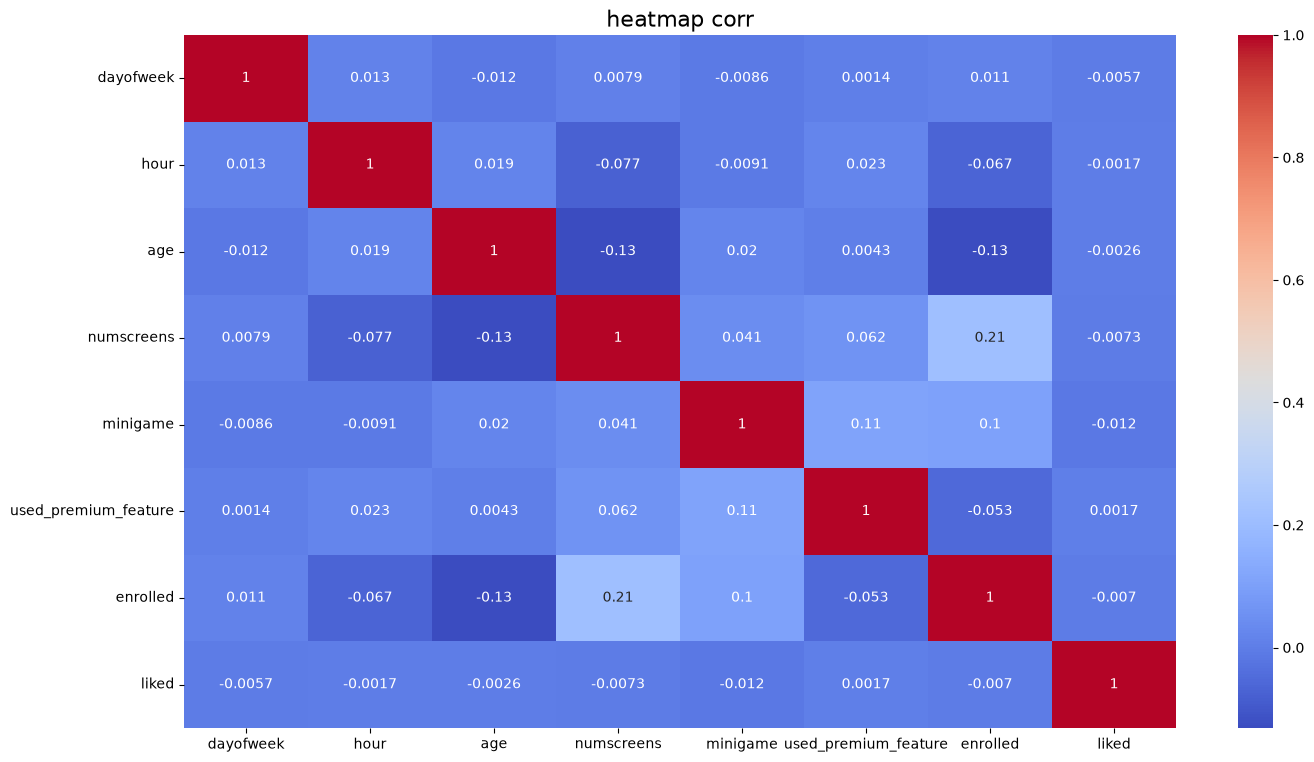

In [16]:
plt.figure(figsize=(16,9))
plt.title('heatmap corr', fontsize=16)
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm')

In [ ]:
"""
In the df2 dataset, there is no strong correlation between any features. There is little correlation between ‘numscreens’ and 
‘enrolled’. It means that those customers saw more screen they are taking premium app. There is a slight correlation between ‘minigame’ with 
‘enrolled’ and ‘used_premium_feature’. The slightly negative correlation between ‘age’ with ‘enrolled’ and ‘numscreens’. It means that older 
customers do not use the premium app and they don’t see multiple screens.
"""

### Pairplot

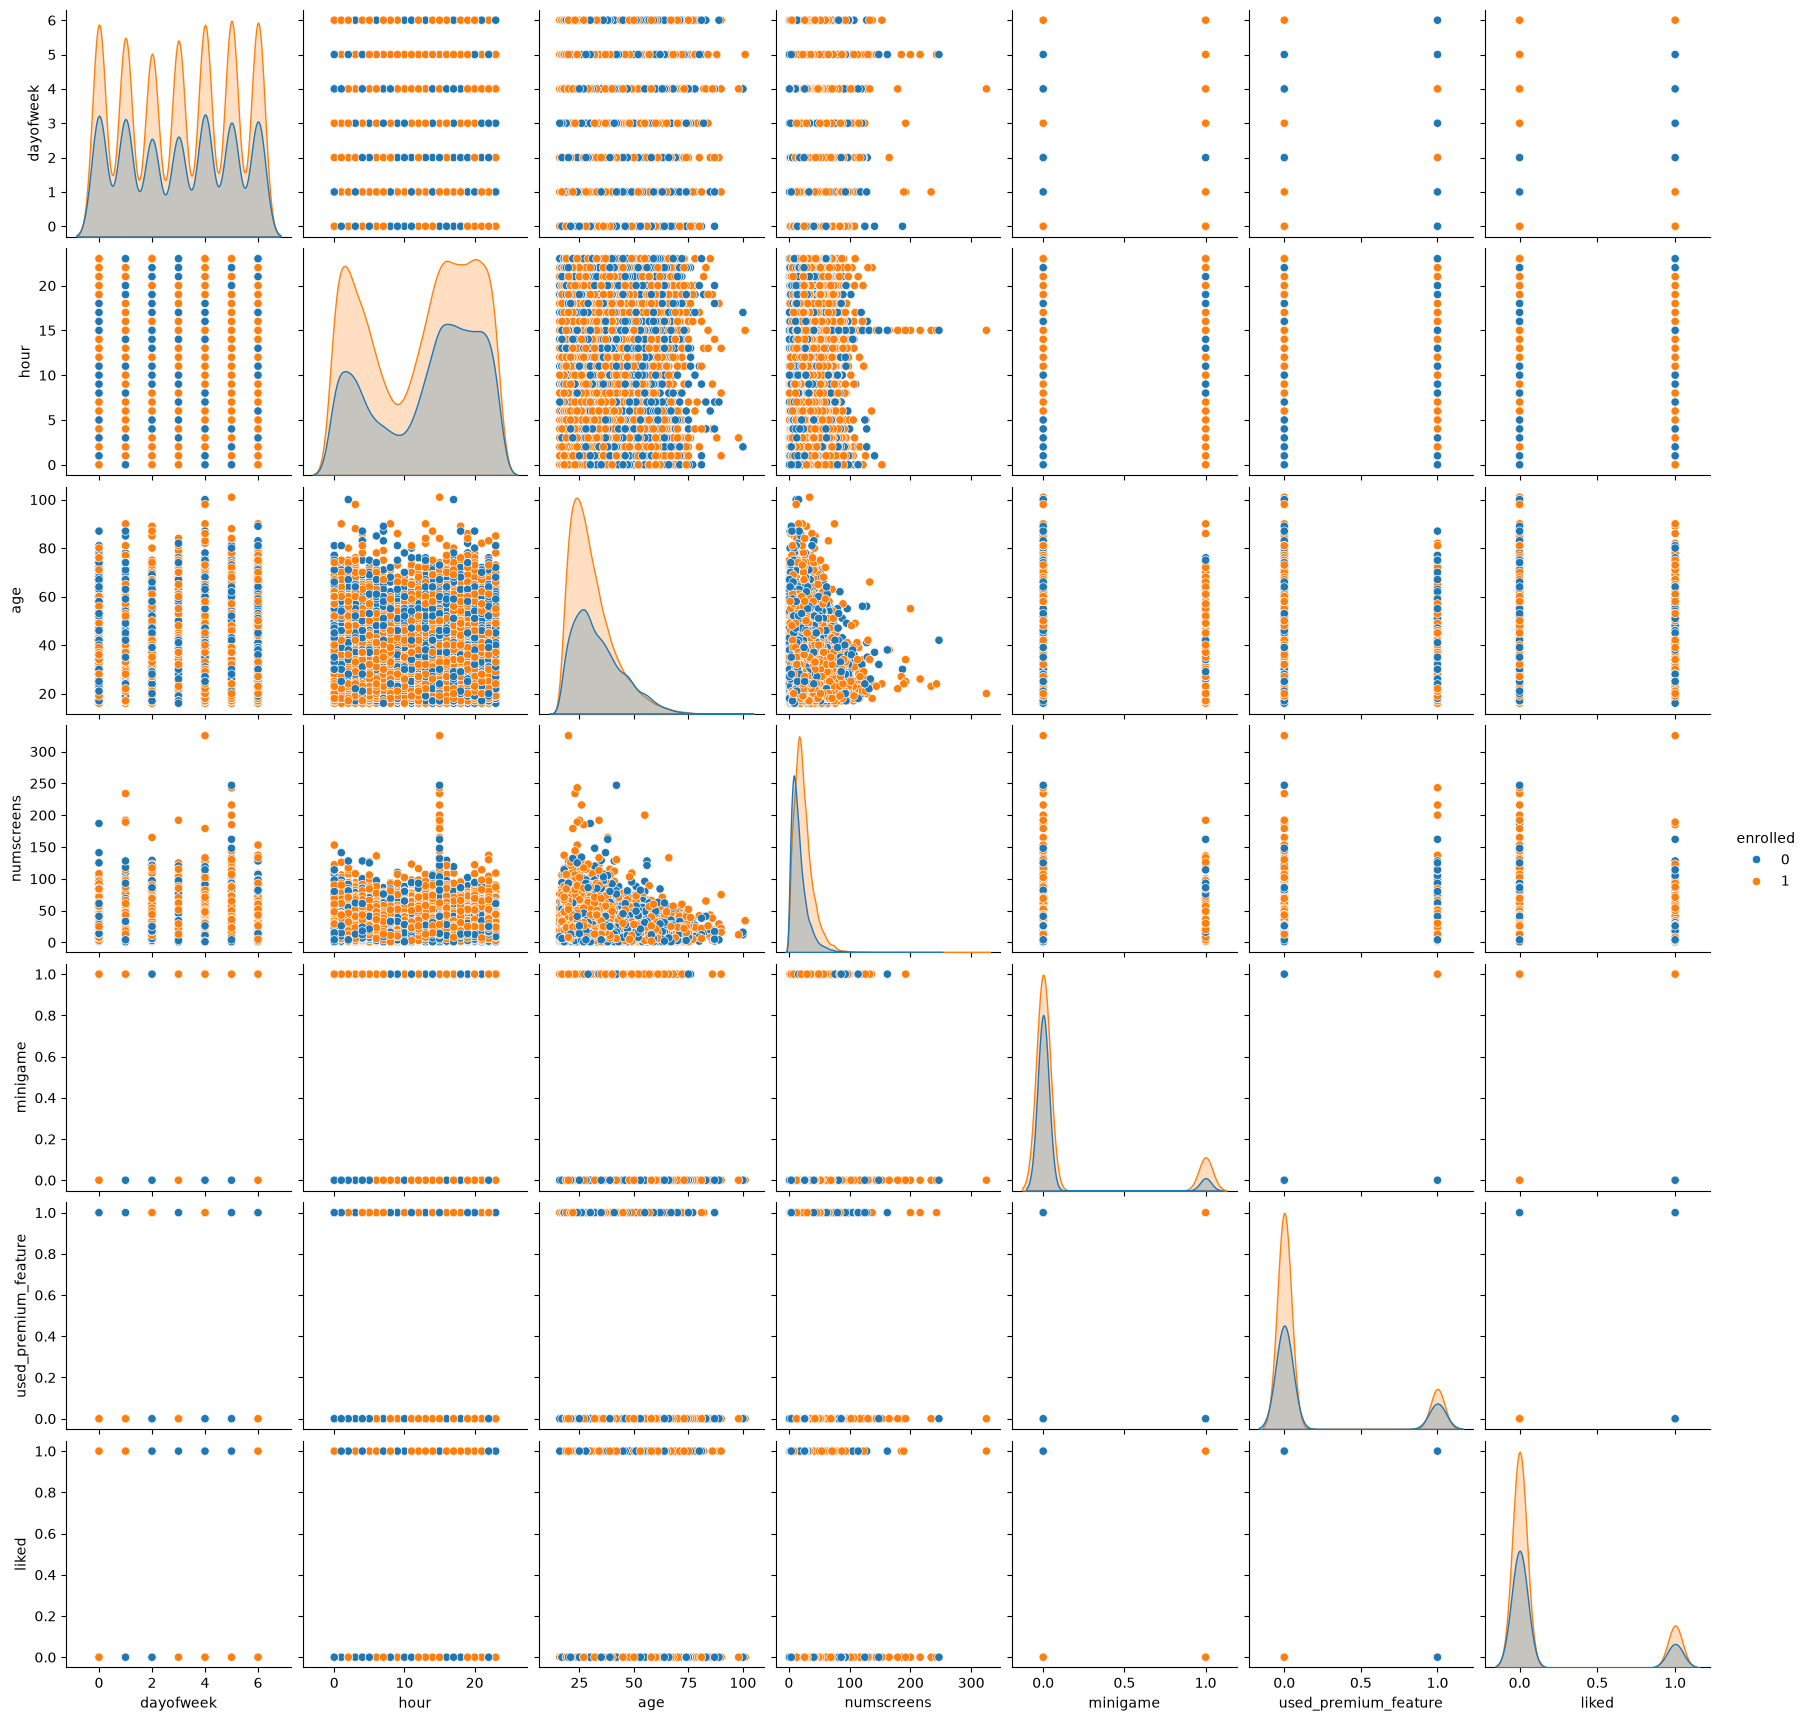

In [17]:
sns.pairplot(df2, hue='enrolled')

In [ ]:
# In pair plot we can see, the maximum features have two values like 0 and 1 and orange dots show the enrolled customer’s features. 
# So we visualize the counterplot of enrolled data.

In [18]:
# Show enrolled & not enrolled feature

print('Enrolled user: ', (df2.enrolled==1).sum())
print('Not Enrolled user: ', df2.shape[0]-(df2.enrolled==1).sum())

Enrolled user:  31074
Not Enrolled user:  18926


### Histogram of each features of fintech_app.

In pairplot, we saw the distribution of each features but here we visualize it easily.

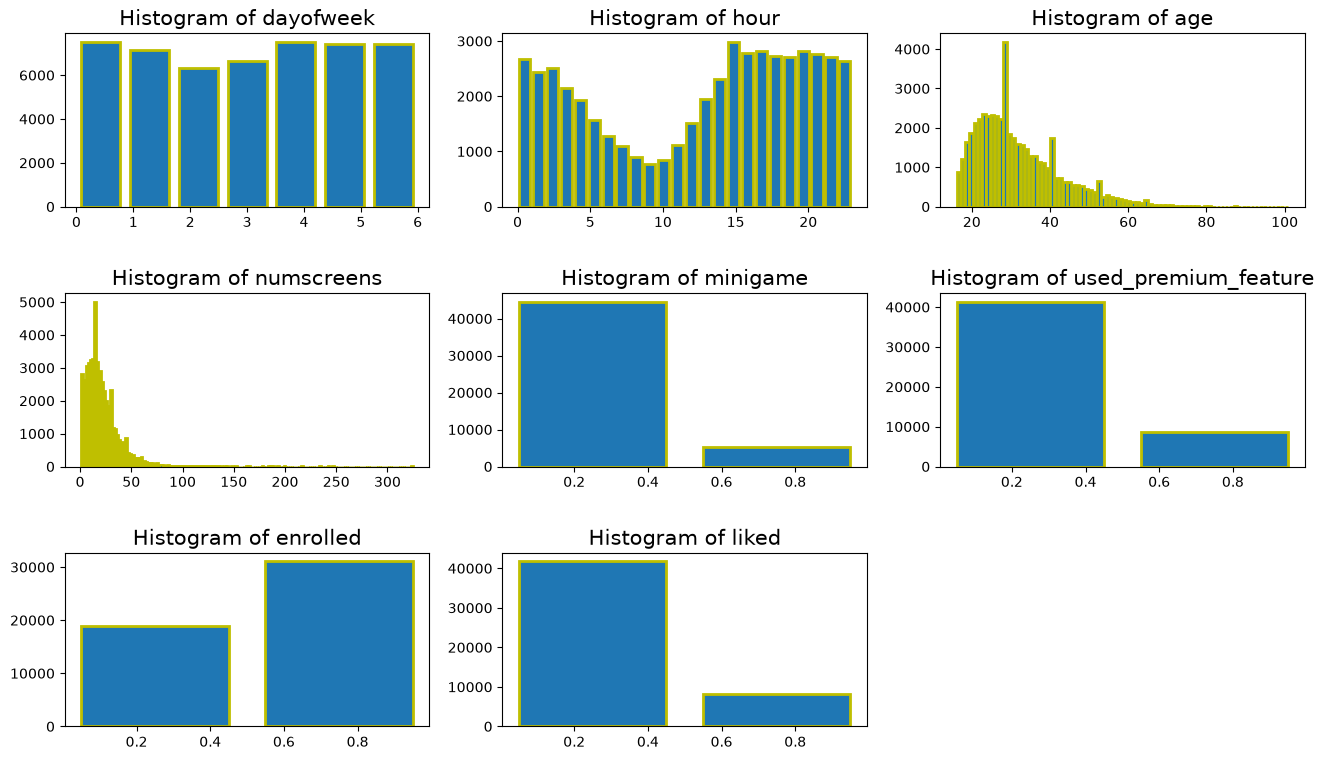

In [8]:
plt.figure(figsize=(16,9))
features = df2.columns
for i,j in enumerate(features):
    plt.subplot(3,3,i+1)
    plt.title('Histogram of {}'.format(j), fontsize=15)
    bins= len(df2[j].unique())
    plt.hist(df2[j], bins=bins, rwidth=0.8, edgecolor='y', linewidth=2)
plt.subplots_adjust(hspace=0.5)

In [ ]:
"""

In the above histogram images, we can clearly see that 4 features i.e minigame, used_premium_feature, enrolled and linked has only 2 bars.
The histogram of 'day of week' shows slightly less customers registered the app on Tuesday and wednsday.
The histogram of 'hour' shows that around 10am, less customer registered app.
The histogram of 'age' shows, younger only registered the app mostly.
'Num Screen' histogram shows only few customers saw more than 40 screens.

"""

### Correlation barplot with Enrolled feature

In [12]:
# Now we are trying to see which feature has strong correlation with enrolled.

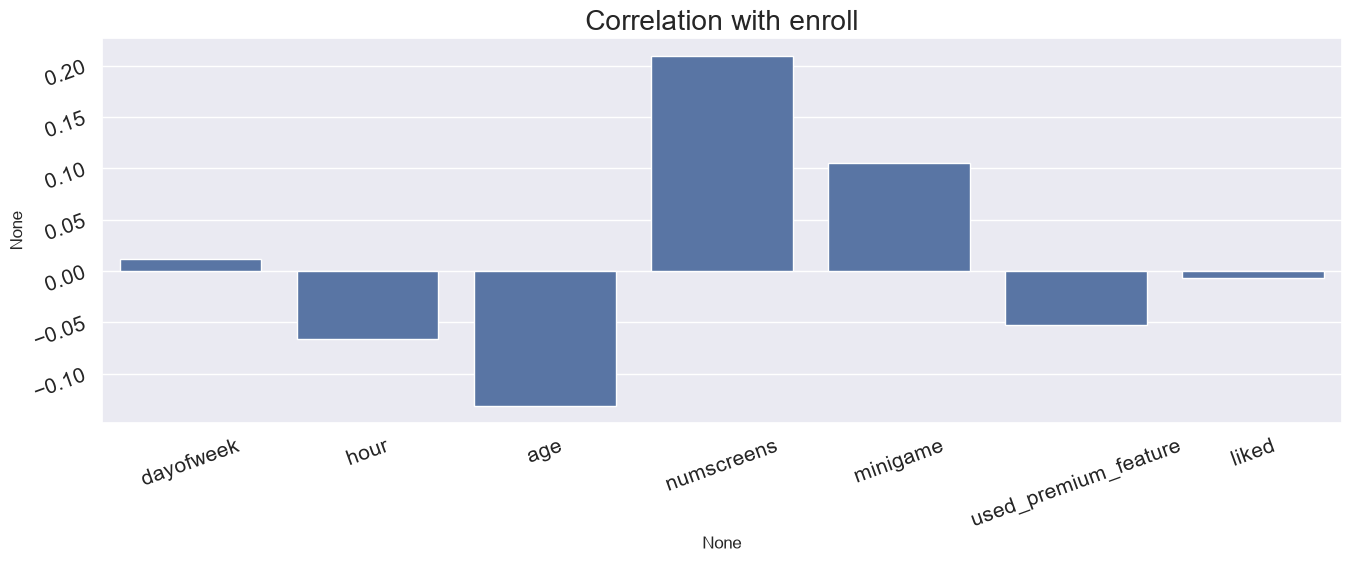

In [30]:
sns.set()
plt.figure(figsize=(16,5))
plt.title('Correlation with enroll', fontsize=20)
df3 = df2.drop(['enrolled'], axis=1)
ax = sns.barplot(x= df3.columns, y= df3.corrwith(df2.enrolled))
ax.tick_params(labelsize=15, labelrotation = 20, color ="k")

In [ ]:
"""
We saw the heatmap correlation matrix but this was not showing correlation clearly but you can easily understand which feature is how much correlated 
with ‘enrolled’ feature using the above barplot.
The ‘numscreens’ and ‘minigame’ is strongly positively correlated with ‘enrolled’ feature than other feature.
The ‘hour’, ‘age’ and ‘used_premium_feature’ are strongly negatively correlated with the ‘enrolled’ feature.
"""

In [5]:
# Now, we are parsing ‘first_open’ and ‘enrolled_date’ object data in date & time format.

df['first_open'] = [parser.parse(i) for i in df['first_open']]
df['enrolled_date'] = [parser.parse(i) if isinstance(i,str) else i for i in df['enrolled_date']]

df.dtypes

user                             int64
first_open              datetime64[ns]
dayofweek                        int64
hour                            object
age                              int64
screen_list                     object
numscreens                       int64
minigame                         int64
used_premium_feature             int64
enrolled                         int64
enrolled_date           datetime64[ns]
liked                            int64
dtype: object

In [ ]:
# We are trying to find how much time the customer takes to get enrolled in the premium feature app after registration. 
# For that subtract ‘fineTech_appData.first_open’ from ‘fineTech_appData.enrolled_date’ and set data type as timedelta64 in hours.

In [6]:
df['time_to_enroll'] = (df.enrolled_date - df.first_open).astype('timedelta64[ns]')
df['time_to_enroll'] = df['time_to_enroll'].dropna().dt.total_seconds() / 3600 # convert to hours

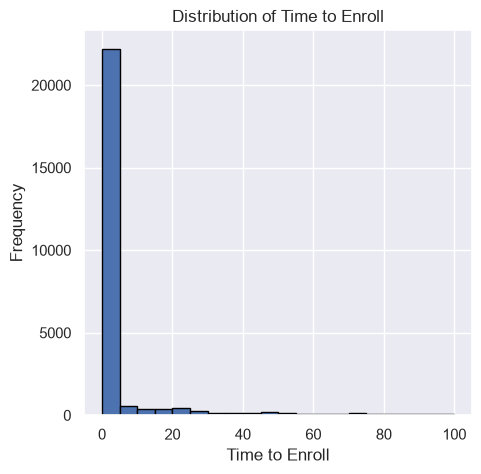

In [51]:
plt.figure(figsize=(5,5))
plt.hist(df['time_to_enroll'].dropna(), bins=20, range=(0, 100), edgecolor='black')
plt.xlabel('Time to Enroll')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Enroll')
plt.show()

### Feature Selection

In [7]:
# we are considering those customers who enrolled after 48hrs as 0.

df.loc[df.time_to_enroll > 48, 'enrolled'] = 0

In [8]:
len(df.loc[df.time_to_enroll > 48])

6287

In [9]:
## read screenlist datasets

screen_df = pd.read_csv(r'C:\neeraj\financial_dataset\top_screens.csv').top_screens.values
screen_df

array(['Loan2', 'location', 'Institutions', 'Credit3Container',
       'VerifyPhone', 'BankVerification', 'VerifyDateOfBirth',
       'ProfilePage', 'VerifyCountry', 'Cycle', 'idscreen',
       'Credit3Dashboard', 'Loan3', 'CC1Category', 'Splash', 'Loan',
       'CC1', 'RewardsContainer', 'Credit3', 'Credit1', 'EditProfile',
       'Credit2', 'Finances', 'CC3', 'Saving9', 'Saving1', 'Alerts',
       'Saving8', 'Saving10', 'Leaderboard', 'Saving4', 'VerifyMobile',
       'VerifyHousing', 'RewardDetail', 'VerifyHousingAmount',
       'ProfileMaritalStatus', 'ProfileChildren ', 'ProfileEducation',
       'Saving7', 'ProfileEducationMajor', 'Rewards', 'AccountView',
       'VerifyAnnualIncome', 'VerifyIncomeType', 'Saving2', 'Saving6',
       'Saving2Amount', 'Saving5', 'ProfileJobTitle', 'Login',
       'ProfileEmploymentLength', 'WebView', 'SecurityModal', 'Loan4',
       'ResendToken', 'TransactionList', 'NetworkFailure', 'ListPicker'],
      dtype=object)

In [24]:
df['screen_list'] = df.screen_list.astype(str)+','

In [ ]:
"""
The ‘Screen_list’ contains string values but we can’t use it directly. So to solve this problem we are taking each screen name from 
‘fineTech_app_screen_Data’ and append as a column by the same name to ‘fineTech_appData’. Then check this screen name is available in 
‘screen_list’ if it is available then add value 1 else 0 in the appended column.
"""

In [25]:
# string to number

for screen_name in screen_df:
    df['screen_name'] = df.screen_list.str.contains(screen_name).astype(int)
    df['screen_list'] = df.screen_list.str.replace(screen_name+",", "")


In [28]:
df.columns

Index(['user', 'first_open', 'dayofweek', 'hour', 'age', 'screen_list',
       'numscreens', 'minigame', 'used_premium_feature', 'enrolled',
       'enrolled_date', 'liked', 'time_to_enroll', 'screen_name'],
      dtype='object')